# Analisis de alquileres scrapeados

Este notebook analiza el archivo generado por el scraper: `data/processed/infocasas_1_dormitorio_detalle.csv`.

El objetivo es revisar todos los tipos de alquiler disponibles en la muestra, no solo apartamentos. Para eso usamos `tipo_propiedad`, `barrio`, `moneda`, `monto`, `gastos_comunes` y `metros_cuadrados`.


Los resultados del analisis se muestran dentro del notebook. No se exportan CSVs ni imagenes derivados para que el outcome sea unico y reproducible desde este archivo.


## 1. Importar librerias y ubicar el proyecto

Esta celda busca la raiz del proyecto para que el notebook funcione aunque se abra desde `notebooks/` o desde la carpeta raiz.


In [1]:
from pathlib import Path
import os
import re

import pandas as pd

def encontrar_raiz_proyecto() -> Path:
    actual = Path.cwd().resolve()
    for ruta in [actual, *actual.parents]:
        if (ruta / 'data' / 'processed' / 'infocasas_1_dormitorio_detalle.csv').exists():
            return ruta
    raise FileNotFoundError('No se encontro data/processed/infocasas_1_dormitorio_detalle.csv')

ROOT_DIR = encontrar_raiz_proyecto()
DATA_PATH = ROOT_DIR / 'data' / 'processed' / 'infocasas_1_dormitorio_detalle.csv'

MPLCONFIG_DIR = ROOT_DIR / 'data' / 'processed' / 'analysis' / 'matplotlib_config'
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPLCONFIG_DIR))

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

ROOT_DIR


WindowsPath('C:/Users/Administrador/Documents/GitHub/Scrapper-alquileres')

## 2. Cargar el dataset crudo


In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Filas: {len(df_raw)}')
print(f'Columnas: {len(df_raw.columns)}')
df_raw.head()


Filas: 21
Columnas: 13


,url,titulo,precio,moneda,monto,barrio,dormitorios,banios,metros_cuadrados,gastos_comunes,tipo_propiedad,referencia,descripcion
0,https://www.infocasas.com.uy/alquiler-de-apart...,"Alquiler de Apartamento en Cordón Sur 10283, 1...",$ 30.000,$,30000,Cordón,1,1,48,NaN,Apartamento,WA5494,Alquiler de Apartamento 1 Dormitorios en Cordó...
1,https://www.infocasas.com.uy/alquiler-de-apart...,Alquiler de apartamento de 1 dormitorio en Cor...,$ 30.000,$,30000,Cordón,1,1,0,$ 3.500,Apartamento,ZCEC70,"Apartamento a estrenar en zona Cordón Sur, Jua..."
2,https://www.infocasas.com.uy/alquiler-apartame...,Alquiler Apartamento 1 Dormitorio en Pocitos N...,$ 33.900,$,33900,Pocitos Nuevo,1,1,43,$ 9.900,Apartamento,OE9C4E,Alquiler de apartamento amoblado de 1 dormitor...
3,https://www.infocasas.com.uy/noi-artes-103-alq...,Noi Artes (103) - Alquiler Apartamento 1 Dormi...,$ 30.500,$,30500,Centro,1,1,43,$ 4.500,Apartamento,T6A0B9,Alquiler Apartamento 1 Dormitorio&nbsp; con Pa...
4,https://www.infocasas.com.uy/alquiler-apartame...,Alquiler apartamento de 1 domitorio en Centro.,$ 21.000,$,21000,Centro,1,1,49,NaN,Apartamento,EB99EC,Viví en una ubicación estratégica de Montevide...


## 3. Limpieza basica

Normalizamos columnas numericas, convertimos gastos comunes a numero y calculamos costo mensual total. Tambien dejamos `precio_m2` como metrica derivada.


In [3]:
def limpiar_monto_gastos(valor):
    if pd.isna(valor):
        return 0.0
    texto = str(valor).strip()
    if not texto:
        return 0.0
    numero = re.sub(r'[^0-9]', '', texto)
    return float(numero) if numero else 0.0

df = df_raw.copy()

for columna in ['monto', 'dormitorios', 'banios', 'metros_cuadrados']:
    df[columna] = pd.to_numeric(df[columna], errors='coerce')

df['gastos_comunes_monto'] = df['gastos_comunes'].apply(limpiar_monto_gastos)
df['costo_mensual_total'] = df['monto'] + df['gastos_comunes_monto']
df.loc[df['metros_cuadrados'] <= 0, 'metros_cuadrados'] = pd.NA
df['precio_m2'] = df['monto'] / df['metros_cuadrados']

df.head()


,url,titulo,precio,moneda,monto,barrio,dormitorios,banios,metros_cuadrados,gastos_comunes,tipo_propiedad,referencia,descripcion,gastos_comunes_monto,costo_mensual_total,precio_m2
0,https://www.infocasas.com.uy/alquiler-de-apart...,"Alquiler de Apartamento en Cordón Sur 10283, 1...",$ 30.000,$,30000,Cordón,1,1,48.0,NaN,Apartamento,WA5494,Alquiler de Apartamento 1 Dormitorios en Cordó...,0.0,30000.0,625.000000
1,https://www.infocasas.com.uy/alquiler-de-apart...,Alquiler de apartamento de 1 dormitorio en Cor...,$ 30.000,$,30000,Cordón,1,1,NaN,$ 3.500,Apartamento,ZCEC70,"Apartamento a estrenar en zona Cordón Sur, Jua...",3500.0,33500.0,NaN
2,https://www.infocasas.com.uy/alquiler-apartame...,Alquiler Apartamento 1 Dormitorio en Pocitos N...,$ 33.900,$,33900,Pocitos Nuevo,1,1,43.0,$ 9.900,Apartamento,OE9C4E,Alquiler de apartamento amoblado de 1 dormitor...,9900.0,43800.0,788.372093
3,https://www.infocasas.com.uy/noi-artes-103-alq...,Noi Artes (103) - Alquiler Apartamento 1 Dormi...,$ 30.500,$,30500,Centro,1,1,43.0,$ 4.500,Apartamento,T6A0B9,Alquiler Apartamento 1 Dormitorio&nbsp; con Pa...,4500.0,35000.0,709.302326
4,https://www.infocasas.com.uy/alquiler-apartame...,Alquiler apartamento de 1 domitorio en Centro.,$ 21.000,$,21000,Centro,1,1,49.0,NaN,Apartamento,EB99EC,Viví en una ubicación estratégica de Montevide...,0.0,21000.0,428.571429


## 4. Calidad de datos


In [4]:
faltantes = df.isna().sum().rename_axis('columna').reset_index(name='faltantes')
faltantes


,columna,faltantes
0,url,0
1,titulo,0
2,precio,0
3,moneda,0
4,monto,0
5,barrio,0
6,dormitorios,0
7,banios,0
8,metros_cuadrados,2
9,gastos_comunes,5


## 5. Composicion de la muestra

Primero miramos que tipos de propiedad y barrios aparecen. Esto define que comparaciones tienen sentido.


In [5]:
conteo_tipo = df['tipo_propiedad'].value_counts(dropna=False).rename_axis('tipo_propiedad').reset_index(name='cantidad')
conteo_barrio = df['barrio'].value_counts(dropna=False).rename_axis('barrio').reset_index(name='cantidad')


display(conteo_tipo)
display(conteo_barrio.head(15))


,tipo_propiedad,cantidad
0,Apartamento,20
1,Casa,1


,barrio,cantidad
0,Punta Carretas,4
1,Cordón,3
2,Pocitos Nuevo,2
3,Centro,2
4,Pocitos,2
5,Parque Batlle,1
6,Carrasco,1
7,Unión,1
8,Shangrilá,1
9,Carrasco Norte,1


## 6. Revision de moneda

No conviene comparar precios en pesos y dolares como si fueran la misma unidad. Primero analizamos por moneda.


In [6]:
df['moneda'].value_counts(dropna=False)


moneda
$      16
U$S     5
Name: count, dtype: int64

## 7. Precio por tipo de propiedad


In [7]:
precio_tipo = (
    df.groupby(['moneda', 'tipo_propiedad'], dropna=False)['monto']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)
precio_tipo


,moneda,tipo_propiedad,count,mean,median,min,max
0,$,Apartamento,15,31859.333333,30500.0,21000,40500
1,$,Casa,1,29000.000000,29000.0,29000,29000
2,U$S,Apartamento,5,1948.000000,1350.0,890,5000


## 8. Precio por barrio


In [8]:
precio_barrio = (
    df.groupby(['moneda', 'barrio'], dropna=False)['monto']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
    .sort_values(['moneda', 'median'], na_position='last')
)
precio_barrio


,moneda,barrio,count,mean,median,min,max
4,$,Parque Batlle,1,23000.000000,23000.0,23000,23000
0,$,Carrasco Norte,1,24500.000000,24500.0,24500,24500
1,$,Centro,2,25750.000000,25750.0,21000,30500
10,$,Villa Dolores,1,29000.000000,29000.0,29000,29000
2,$,Cordón,3,28996.666667,30000.0,26990,30000
5,$,Pocitos,1,30000.000000,30000.0,30000,30000
9,$,Unión,1,34000.000000,34000.0,34000,34000
8,$,Shangrilá,1,36000.000000,36000.0,36000,36000
6,$,Pocitos Nuevo,2,36450.000000,36450.0,33900,39000
3,$,Golf,1,38500.000000,38500.0,38500,38500


## 9. Costo mensual total


In [9]:
costo_total_barrio = (
    df.groupby(['moneda', 'barrio'], dropna=False)['costo_mensual_total']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
    .sort_values(['moneda', 'median'], na_position='last')
)
costo_total_barrio


,moneda,barrio,count,mean,median,min,max
0,$,Carrasco Norte,1,26500.0,26500.0,26500.0,26500.0
4,$,Parque Batlle,1,26500.0,26500.0,26500.0,26500.0
1,$,Centro,2,28000.0,28000.0,21000.0,35000.0
10,$,Villa Dolores,1,29000.0,29000.0,29000.0,29000.0
2,$,Cordón,3,32030.0,32590.0,30000.0,33500.0
5,$,Pocitos,1,36500.0,36500.0,36500.0,36500.0
9,$,Unión,1,39150.0,39150.0,39150.0,39150.0
8,$,Shangrilá,1,41700.0,41700.0,41700.0,41700.0
7,$,Punta Carretas,2,43500.0,43500.0,40500.0,46500.0
6,$,Pocitos Nuevo,2,44850.0,44850.0,43800.0,45900.0


## 10. Precio por metro cuadrado


In [10]:
precio_m2_barrio = (
    df.dropna(subset=['precio_m2'])
    .groupby(['moneda', 'barrio'], dropna=False)['precio_m2']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
    .sort_values(['moneda', 'median'], na_position='last')
)
precio_m2_barrio


,moneda,barrio,count,mean,median,min,max
10,$,Villa Dolores,1,414.285714,414.285714,414.285714,414.285714
4,$,Parque Batlle,1,547.619048,547.619048,547.619048,547.619048
1,$,Centro,2,568.936877,568.936877,428.571429,709.302326
5,$,Pocitos,1,600.000000,600.000000,600.000000,600.000000
2,$,Cordón,2,649.875000,649.875000,625.000000,674.750000
9,$,Unión,1,755.555556,755.555556,755.555556,755.555556
3,$,Golf,1,770.000000,770.000000,770.000000,770.000000
0,$,Carrasco Norte,1,790.322581,790.322581,790.322581,790.322581
8,$,Shangrilá,1,800.000000,800.000000,800.000000,800.000000
7,$,Punta Carretas,2,850.320513,850.320513,675.000000,1025.641026


## 11. Graficos

Estos graficos trabajan primero con publicaciones en pesos para no mezclar monedas.


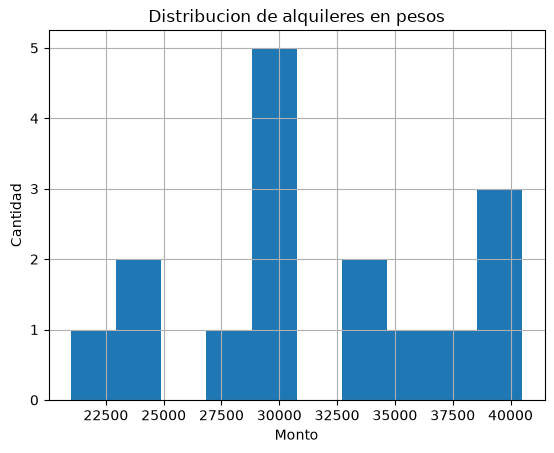

In [11]:
if plt is None:
    print('matplotlib no esta instalado. Instalar con: pip install matplotlib')
else:
    df_pesos = df[df['moneda'] == '$'].copy()
    df_pesos['monto'].dropna().hist()
    plt.title('Distribucion de alquileres en pesos')
    plt.xlabel('Monto')
    plt.ylabel('Cantidad')
    plt.show()


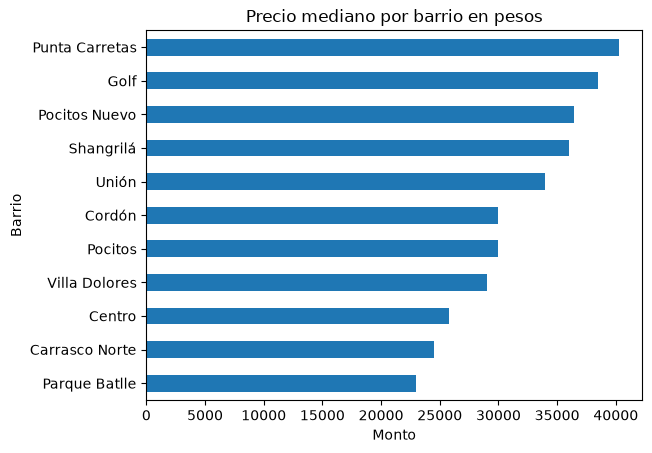

In [12]:
if plt is not None:
    (
        df[df['moneda'] == '$']
        .groupby('barrio')['monto']
        .median()
        .sort_values()
        .plot(kind='barh')
    )
    plt.title('Precio mediano por barrio en pesos')
    plt.xlabel('Monto')
    plt.ylabel('Barrio')
    plt.show()


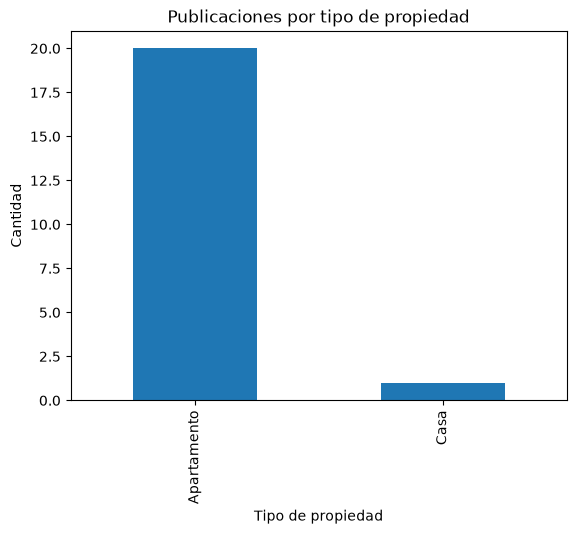

In [13]:
if plt is not None:
    df['tipo_propiedad'].value_counts().plot(kind='bar')
    plt.title('Publicaciones por tipo de propiedad')
    plt.xlabel('Tipo de propiedad')
    plt.ylabel('Cantidad')
    plt.show()


## 12. Lectura inicial

Puntos a revisar antes de sacar conclusiones fuertes:

- La muestra actual es chica y viene de una busqueda especifica.
- Hay que separar precios por moneda o convertirlos a una moneda comun.
- `tipo_propiedad` permite comparar segmentos, pero algunos tipos pueden tener pocos casos.
- `referencia` sirve para deduplicar cuando se amplie el scraping.
- `metros_cuadrados` puede requerir revision manual si la publicacion informa varias superficies.
